# Advanced Macroeconomics
## Dynamic Programming & Reinforcement Learning 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from dynamic_programming.bellman_operator import BellmanOperator
from src.problem.opti_problem import CES

### Question 1 & 2

An agent has the opportunity to allocate her time between producing the consumption good C, and accumulating human capital H. Her intertemporal optimization problem is has follow:

$$\sum_{t=0}^{+\infty} \beta U(C_t)$$

subject to the following constraints: 
1. The production function, $\forall t, C_t = H_t^\alpha L_t$
2. The state transition equation, $\forall t, H_{t+1} = (1-\delta)H_t + 1 - L_t$
3. The control domain, $\forall t, L_{t} \in [0,1]$

Assuming a CRRA utility, the recursive problem is given by:

$$V(H_t) = \max_{L_t \in [0,1]} \left[\frac{(H_t^\alpha L_t)^{1-\sigma}}{1-\sigma} + \beta V((1-\delta)H_t + 1 - L_t)\right]$$

where the value function V is not known and is to determine.

In [3]:
# Grid
grid = np.linspace(1e-3, 5, 4000)

# Initial conditions and shocks
init_w = 0.5 * np.log(grid)

In [25]:
# Computation of the value function
recursive_solver = BellmanOperator(init_w=init_w, grid=grid)
recursive_solver.solve_optgrowth()

Recursive Solver:   0%|          | 0/500 [00:01<?, ?iter/s]


KeyboardInterrupt: 

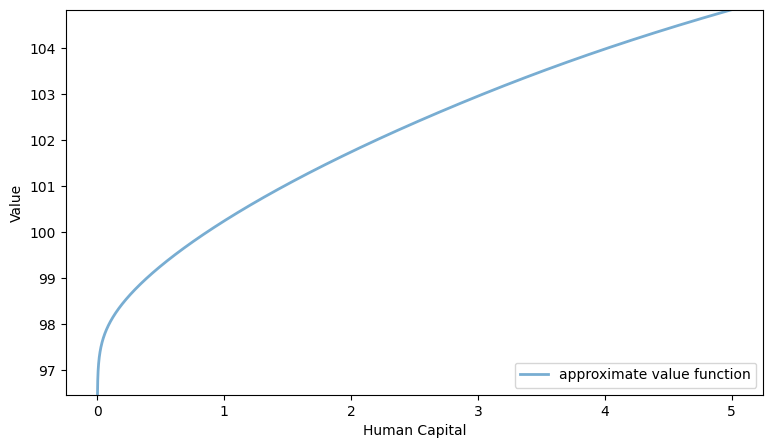

In [4]:
recursive_solver.plot_results("Value")

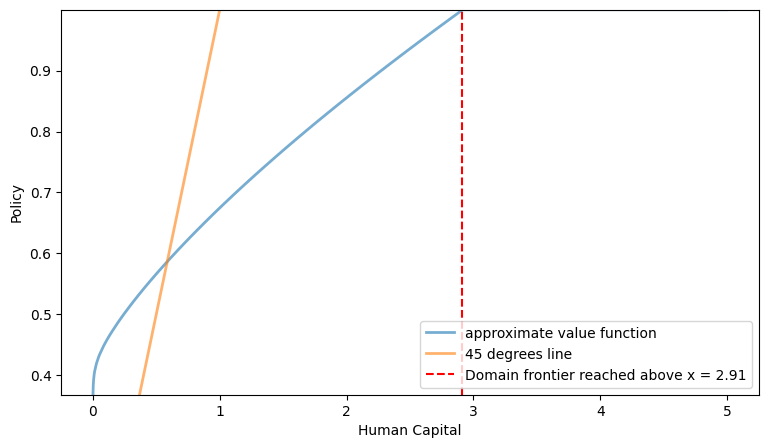

In [5]:
recursive_solver.plot_results("Policy", control_bound=(0, 1 - 1e-3))

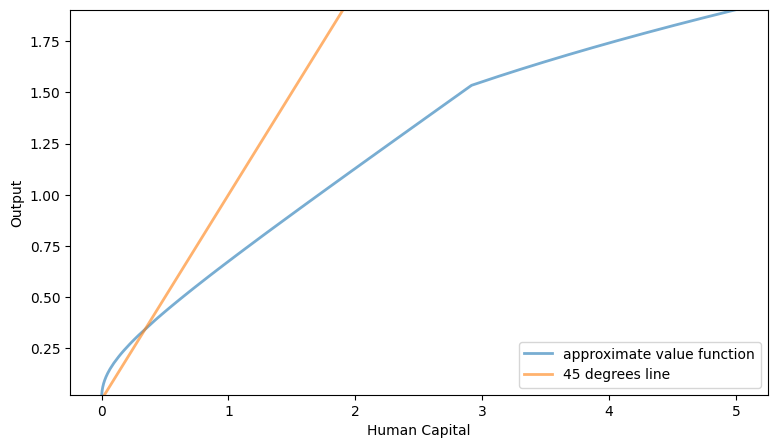

In [6]:
recursive_solver.plot_results("Output")

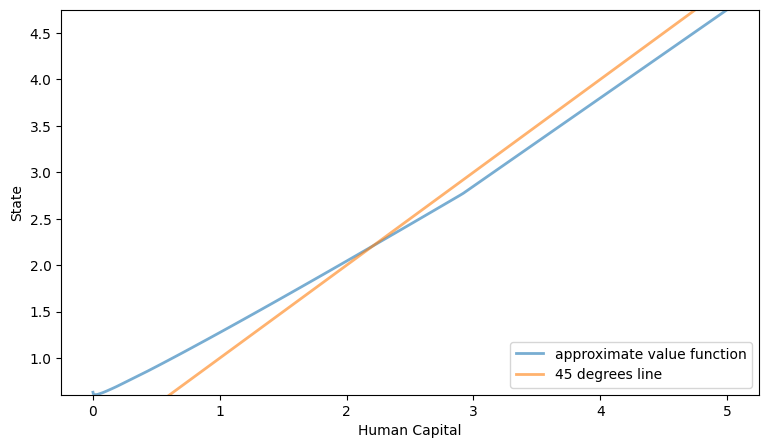

In [7]:
recursive_solver.plot_results("State", control_bound=(0, 1-1e-3))

The recursive methods is valid when the optimal path of control lies in the interior of it's domain. Thus above the red doted line we are not sure about our approximation of the value function.

### Question 3 & 4

$$V(H_t) = \max_{H_{t+1} \in \Gamma(H_t)} \left[\frac{(H_t^\alpha ((1-\delta)H_t + 1 - H_{t+1}))^{1-\sigma}}{1-\sigma} + \beta V(H_{t+1})\right]$$

where $\Gamma(H_t) = [(1-\delta)H_t, (1-\delta)H_t + 1]$


In [4]:
from src.dynamic_programming.epsilon_greedy import EpsilonGreedy

In [9]:
greedy_solver = EpsilonGreedy(init_w=init_w, grid=grid, epsilon=0)

Greedy Solver:   0%|          | 0/200 [00:00<?, ?iter/s]

109


Greedy Solver:   0%|          | 1/200 [00:01<04:29,  1.35s/iter, Error=0.682]

50


Greedy Solver:   1%|          | 2/200 [00:02<04:06,  1.24s/iter, Error=0.682]

...

Greedy Solver:   6%|▌         | 11/200 [00:10<02:23,  1.32iter/s, Error=0.00386]

3


Greedy Solver:   6%|▌         | 12/200 [00:10<02:17,  1.37iter/s, Error=0.00386]

1


Greedy Solver:   6%|▋         | 13/200 [00:11<02:46,  1.12iter/s, Error=4.29e-5]


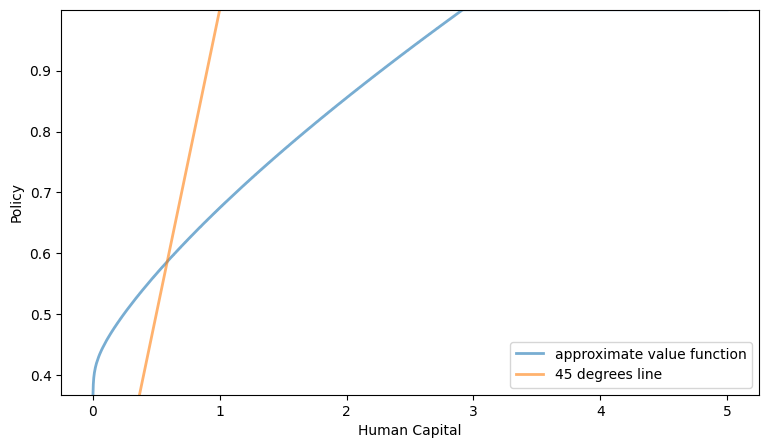

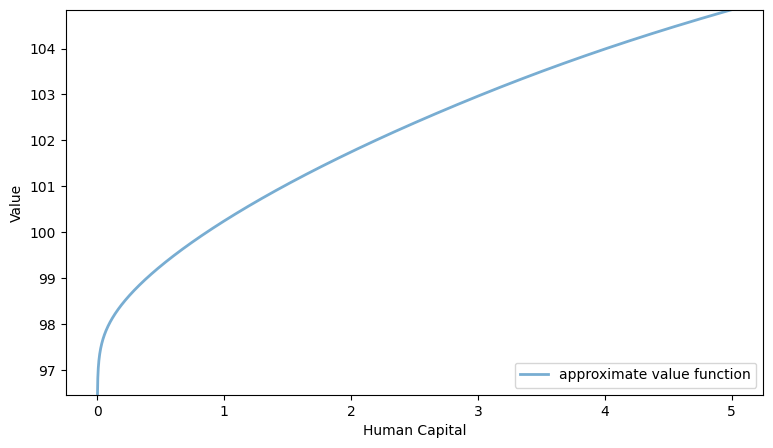

In [13]:
greedy_solver.solve_optgrowth(max_iter=200)
greedy_solver.plot_results("Policy")
greedy_solver.plot_results("Value")